In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from PIL import Image
from torchvision import transforms

from src.models.binary_roi_classifier import build_binary_classifier

sns.set_theme(style="white", palette="Blues_r")

CHECKPOINT_PATH = Path("runs/binary/mouth/best.pt")
DATASET_ROOT    = Path("../cropped_images_test/mouth")
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_DIRS   = {"closed": 0, "open": 1}
CLASS_LABELS = {0: "eyes_closed", 1: "eyes_open"}

TRANSFORM = transforms.Compose([
    transforms.Resize((32, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

## Load model

In [6]:
model = build_binary_classifier(pretrained=False, freeze_backbone=False).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print(f"Loaded checkpoint: {CHECKPOINT_PATH}")

Loaded checkpoint: runs\binary\mouth\best.pt


## Run inference on full dataset

In [7]:
p_positive_all = []
true_labels_all = []
img_paths_all = []

with torch.no_grad():
    for class_dir, true_label in CLASS_DIRS.items():
        for img_path in sorted((DATASET_ROOT / class_dir).glob("*.jpg")):
            img = TRANSFORM(Image.open(img_path).convert("L").convert("RGB")).unsqueeze(0).to(DEVICE)
            logits = model(img)
            probs = torch.softmax(logits, dim=-1)
            p_positive_all.append(probs[0, 0].item())
            true_labels_all.append(true_label)
            img_paths_all.append(img_path)

p_positive_all  = np.array(p_positive_all)
true_labels_all = np.array(true_labels_all)
print(f"Total samples: {len(p_positive_all)}")

Total samples: 3037


In [8]:
p_positive_all[:100]

array([0.99341875, 0.99916983, 0.99967778, 0.99871469, 0.98988682,
       0.99888021, 0.9187417 , 0.98990309, 0.99488562, 0.99744308,
       0.98484832, 0.98578936, 0.99366331, 0.99562305, 0.98776883,
       0.99656361, 0.99558216, 0.99012381, 0.98650533, 0.96488047,
       0.99710876, 0.97230119, 0.99809378, 0.90761137, 0.91318941,
       0.99267936, 0.99226874, 0.9864586 , 0.99679154, 0.98966449,
       0.99551916, 0.99120164, 0.98532712, 0.88152224, 0.98083305,
       0.98390627, 0.94774079, 0.93345094, 0.99755716, 0.99752909,
       0.9661606 , 0.97304505, 0.99582231, 0.95937335, 0.9937551 ,
       0.99686521, 0.98635477, 0.98352605, 0.99781227, 0.99406999,
       0.99577624, 0.99929869, 0.99999774, 0.99818039, 0.99586821,
       0.99814248, 0.95765042, 0.99548268, 0.94232571, 0.21212064,
       0.99758279, 0.94905555, 0.97638595, 0.98523074, 0.99035978,
       0.99767309, 0.99519449, 0.99663562, 0.98357242, 0.95876586,
       0.99549145, 0.9788962 , 0.99419385, 0.99685681, 0.95686

## Distribution 1 — Raw p_positive by true class

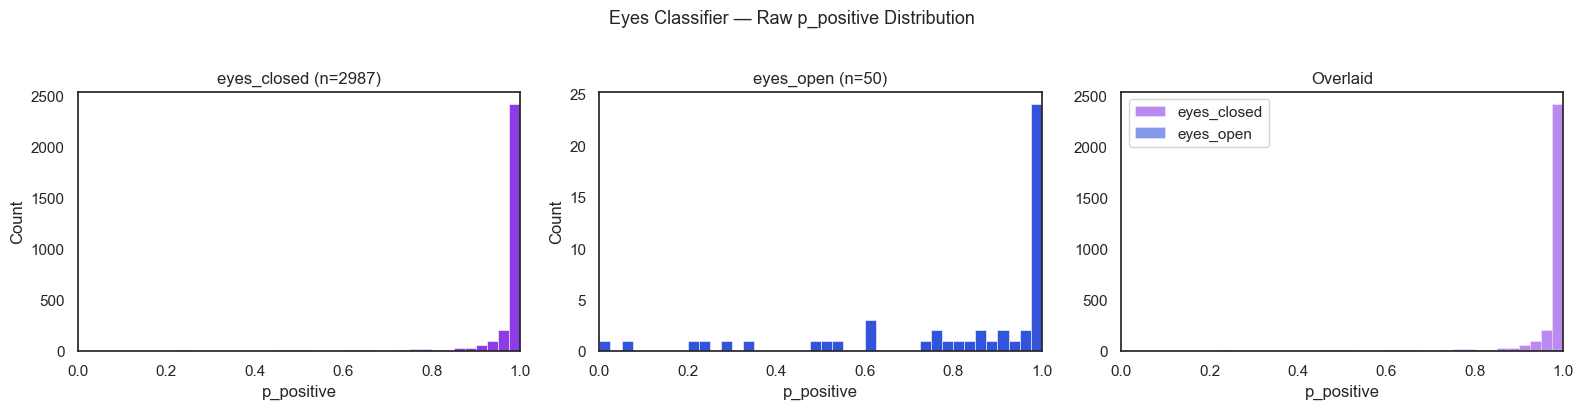

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = {0: "#8c3ce7", 1: "#3453db"}
bins = np.linspace(0, 1, 41)

# Per-class histograms
for label, name in CLASS_LABELS.items():
    mask = true_labels_all == label
    axes[label].hist(p_positive_all[mask], bins=bins, color=colors[label], edgecolor="white", linewidth=0.4)
    axes[label].set_title(f"{name} (n={mask.sum()})")
    axes[label].set_xlabel("p_positive")
    axes[label].set_ylabel("Count")
    axes[label].set_xlim(0, 1)

# Overlaid
for label, name in CLASS_LABELS.items():
    mask = true_labels_all == label
    axes[2].hist(p_positive_all[mask], bins=bins, color=colors[label], alpha=0.6, edgecolor="white", linewidth=0.4, label=name)
axes[2].set_title("Overlaid")
axes[2].set_xlabel("p_positive")
axes[2].set_xlim(0, 1)
axes[2].legend()

plt.suptitle("Eyes Classifier — Raw p_positive Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10×10 Classification Grid

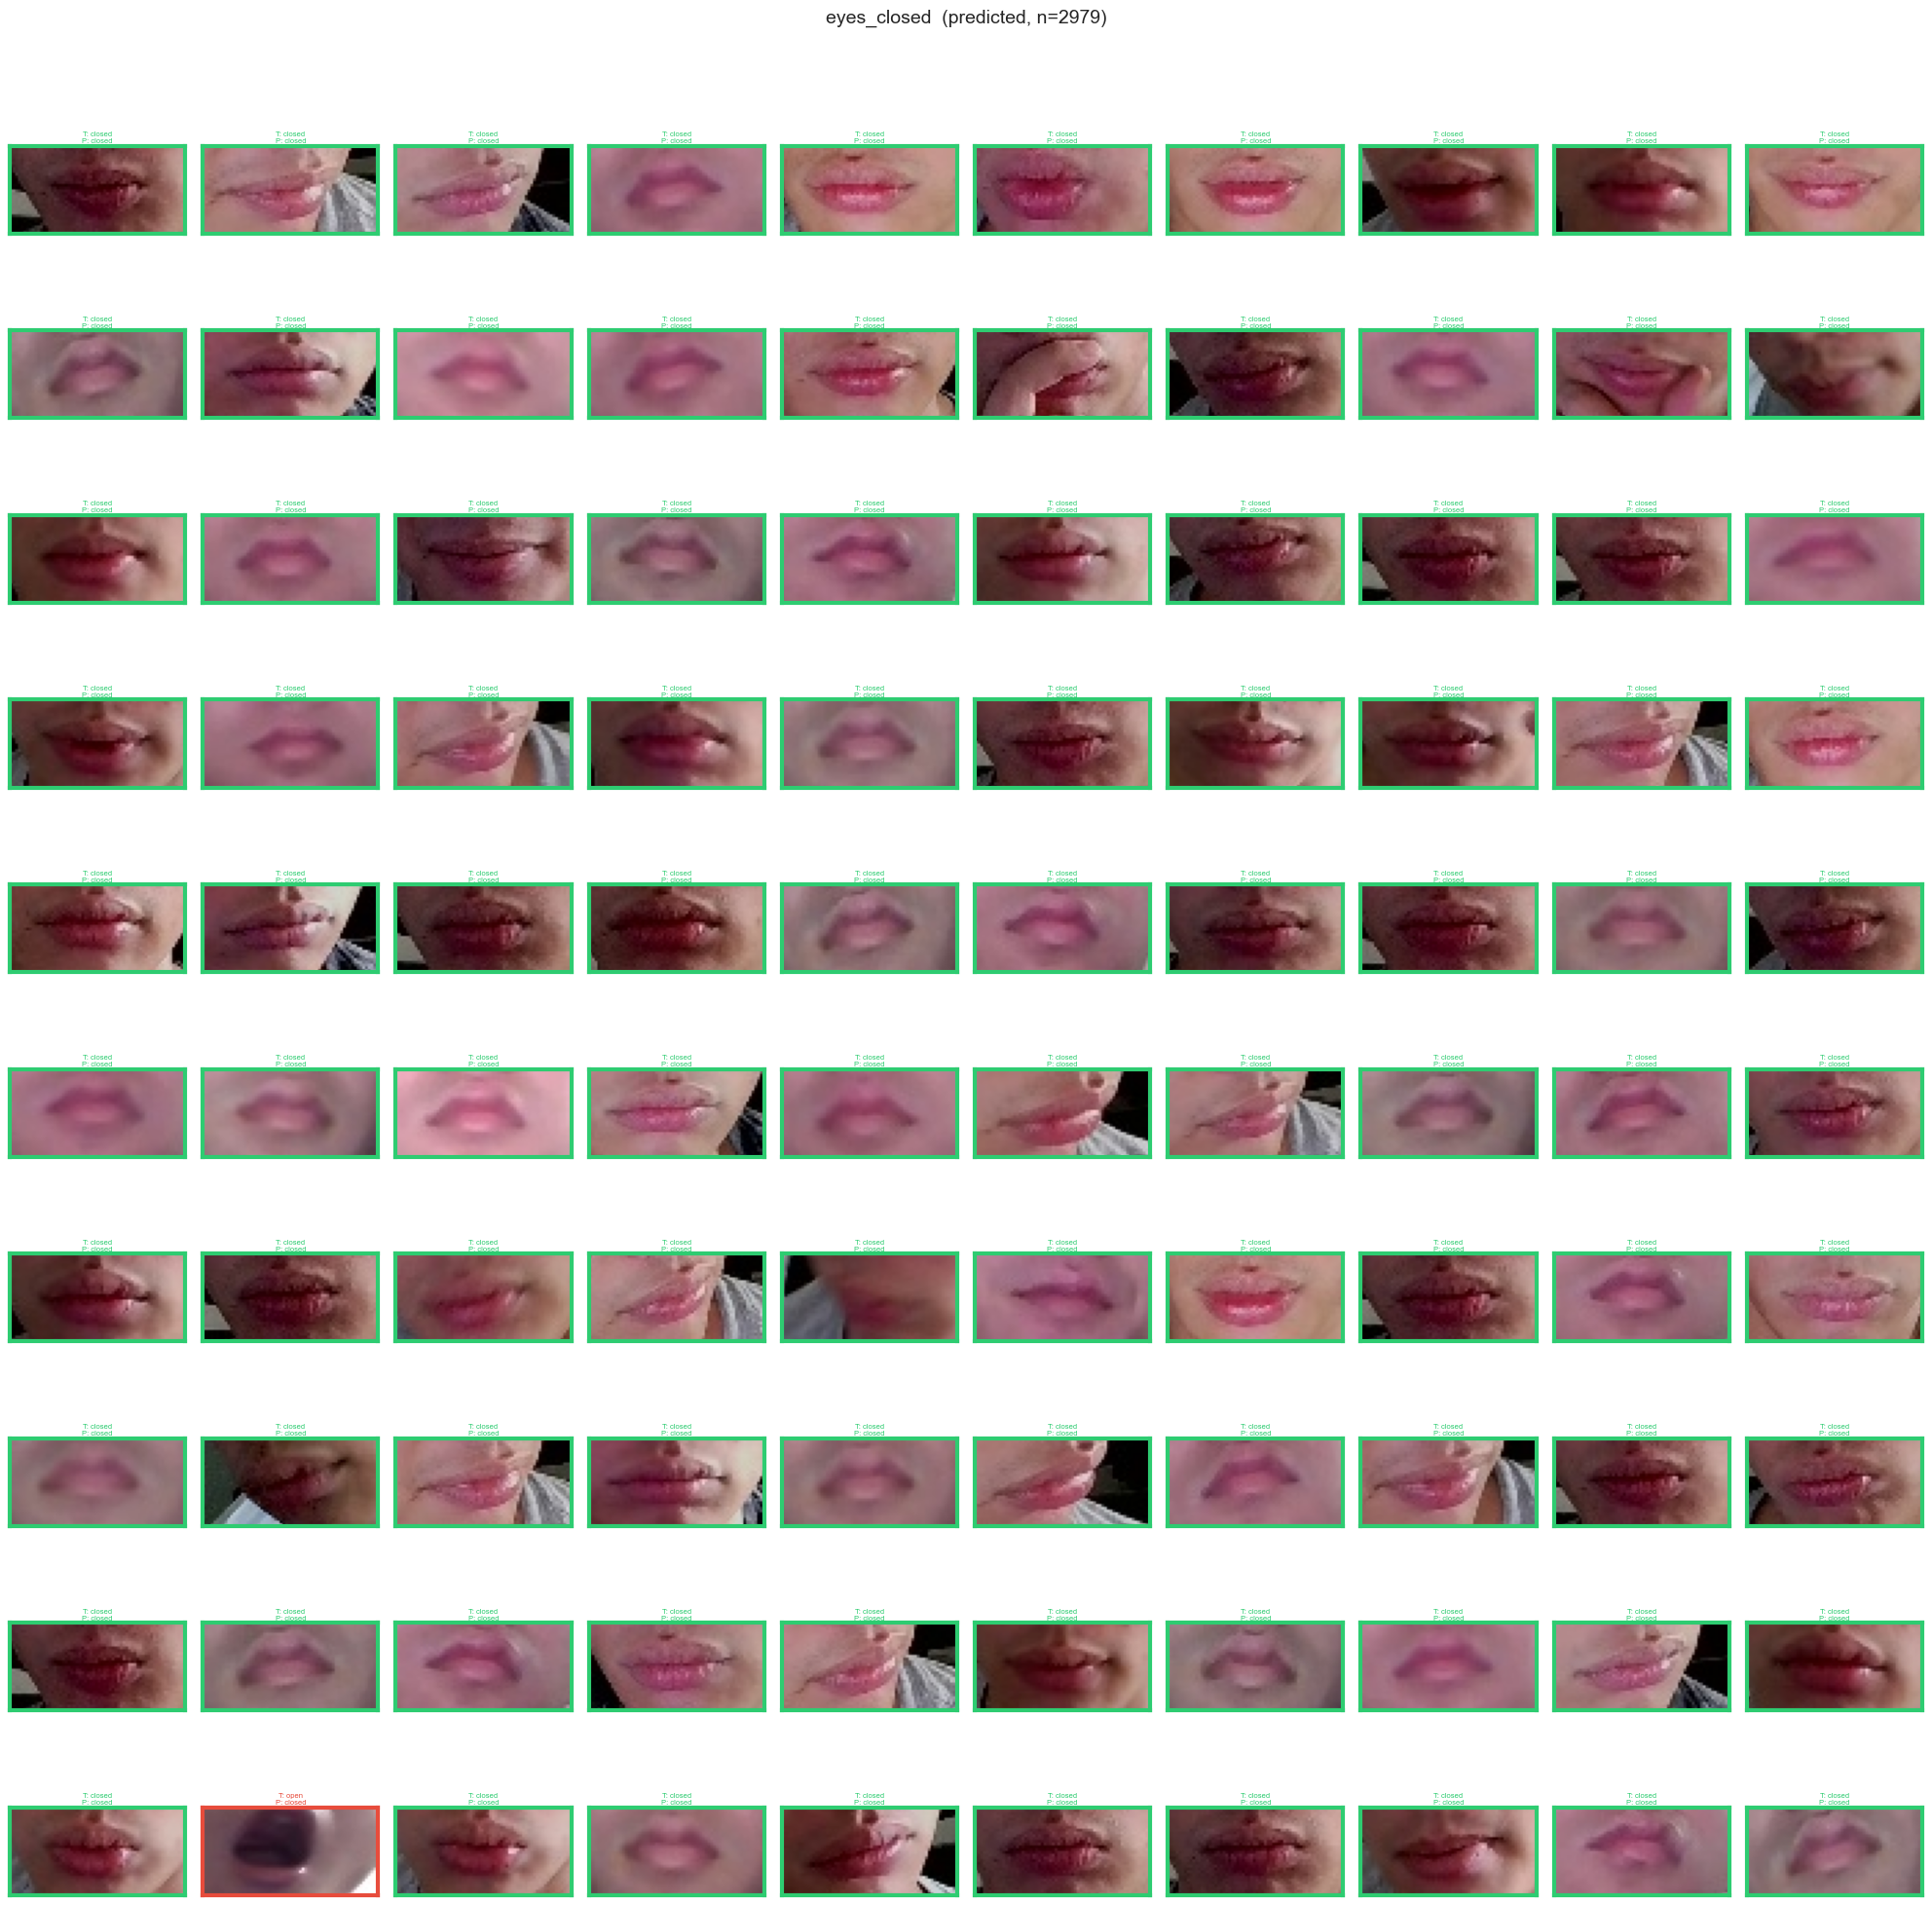

eyes_closed: 99/100 correct (99%)


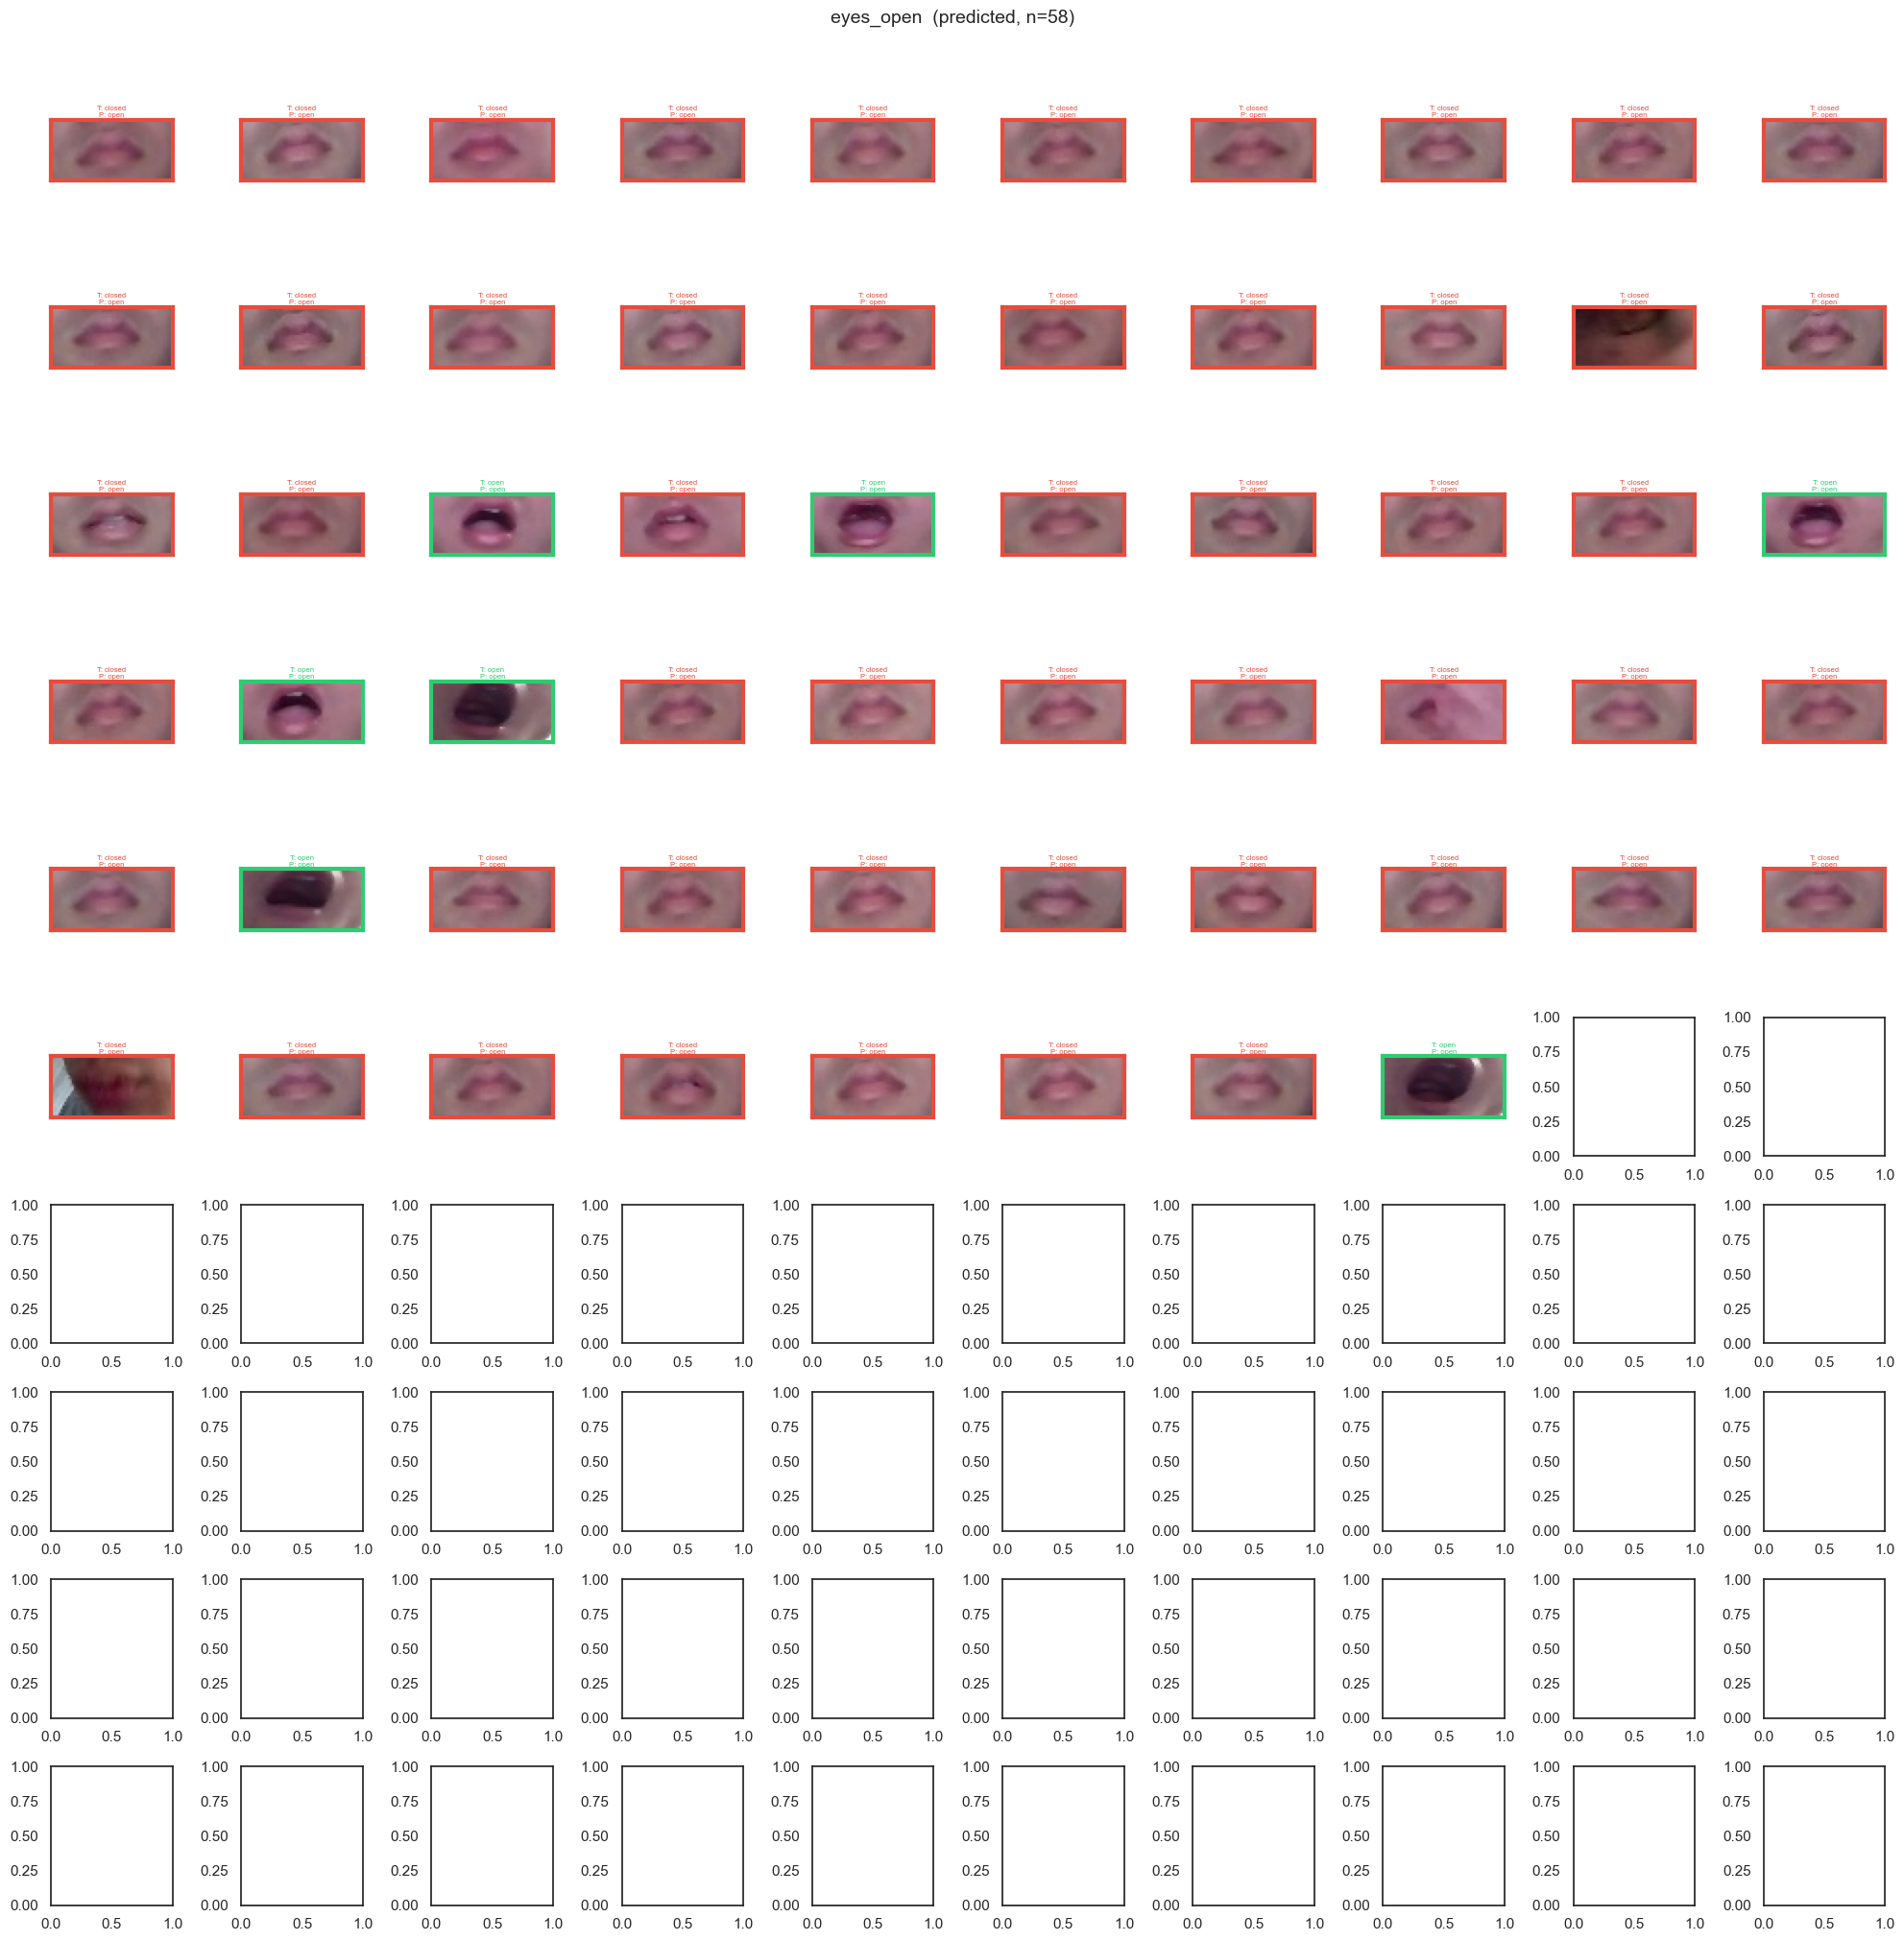

eyes_open: 7/58 correct (7%)


In [10]:
import random

records = [
    {
        "path":  img_paths_all[i],
        "true":  CLASS_LABELS[true_labels_all[i]],
        "pred":  "eyes_closed" if p_positive_all[i] > 0.5 else "eyes_open",
        "p_pos": p_positive_all[i],
    }
    for i in range(len(img_paths_all))
]

by_pred = {"eyes_closed": [], "eyes_open": []}
for r in records:
    by_pred[r["pred"]].append(r)

for cls, cls_records in by_pred.items():
    sample = random.sample(cls_records, min(100, len(cls_records)))

    fig, axes = plt.subplots(10, 10, figsize=(20, 20))
    fig.suptitle(f"{cls}  (predicted, n={len(cls_records)})", fontsize=14, y=1.01)

    for ax, rec in zip(axes.flat, sample):
        img = Image.open(rec["path"]).convert("RGB")
        ax.imshow(img)

        correct = rec["pred"] == rec["true"]
        border_color = "#2ecc71" if correct else "#e74c3c"

        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(
            f"T: {rec['true'].replace('eyes_', '')}\nP: {rec['pred'].replace('eyes_', '')}",
            fontsize=5.5,
            color=border_color,
            pad=2,
        )

    plt.tight_layout()
    plt.show()

    correct_count = sum(r["pred"] == r["true"] for r in sample)
    print(f"{cls}: {correct_count}/{len(sample)} correct ({correct_count}%)")

## Binary Classification Metrics

              precision    recall  f1-score   support

 eyes_closed       0.28      0.06      0.10       412
   eyes_open       0.94      0.99      0.96      5662

    accuracy                           0.93      6074
   macro avg       0.61      0.53      0.53      6074
weighted avg       0.89      0.93      0.90      6074



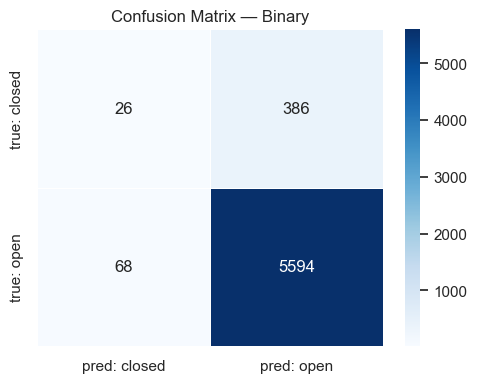

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="white")

# Binary prediction: argmax (p_pos > 0.5 → eyes_closed=0, else eyes_open=1)
binary_preds = (p_positive_all <= 0.5).astype(int)  # 0=closed, 1=open
true_binary = true_labels_all  # already 0=closed, 1=open

report = classification_report(
    true_binary,
    binary_preds,
    target_names=["eyes_closed", "eyes_open"],
    zero_division=0,
)
print(report)

# Confusion matrix
cm = confusion_matrix(true_binary, binary_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred: closed", "pred: open"],
    yticklabels=["true: closed", "true: open"],
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Confusion Matrix — Binary")
plt.tight_layout()
plt.show()